In [1]:
# magics: ensures that any changes to the modules loaded below will be re-loaded automatically
%load_ext autoreload
%autoreload 2

%load_ext line_profiler

# load general packages
import numpy as np

# load modules related to this exercise
from  matplotlib.pyplot import spy
from model_zucher import zurcher
import Estimate_MPEC as estimate_MPEC

from Solve_NFXP import solve_NFXP
import estimate_NFXP as estimate_NFXP

# Exercise set 4


In [2]:
model = zurcher()
solver = solve_NFXP()

#  SIMULATE DATA
N = 500
T = 120
v0 = np.zeros((model.n,))
ev, pk = solver.poly(model.bellman,v0, beta=model.beta, output=2)
data = zurcher.sim_data(model,N,T,pk) 
samplesize = data.shape[0]



#### 1. Run the function mpec.sparsity_pattern.
The function mpec.sparsity_pattern creates sparse matrices of indicators for where there are elements in the Jacobian of the constraints and Hessian of the likelihood function

(a) Look at the figures, and discuss what the different elements of the constraint Jacobian and likelihood Hessian represent.

**Answer.** Each Bellman constraint depends directly on the structural parameters and only on the expected-value elements reachable through the transition matrix, producing a banded Jacobian plus the replacement-state column. The likelihood couples the utility parameters with the value variables entering the observed choice probabilities, while most pairs of distant value variables never interact. These local dependencies generate the sparse patterns shown below.

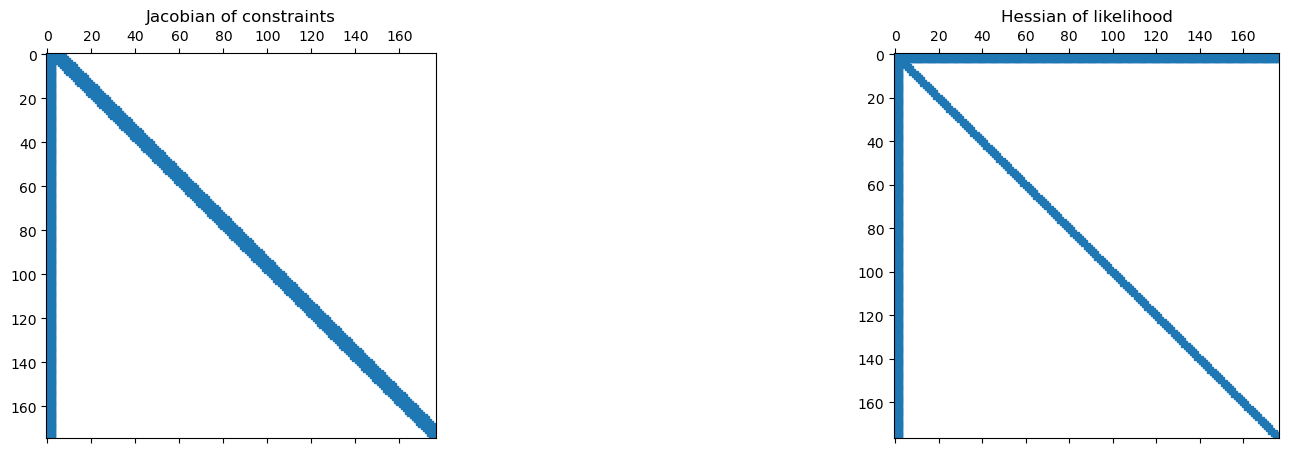

In [3]:
# Number of parameter to be estimated
Nc = 2

import matplotlib.pyplot as plt

J_pattern, H_pattern = estimate_MPEC.sparsity_pattern(Nc,model.n, len(model.p)+1)

# Figure
fig = plt.figure(figsize=(20,5))# figsize is in inches...

ax = fig.add_subplot(1,2,1)
ax.spy(J_pattern,markersize=5)
ax.set_title(f'Jacobian of constraints')
ax = fig.add_subplot(1,2,2)
ax.spy(H_pattern,markersize=5)
ax.set_title(f'Hessian of likelihood')
plt.show()

#### 2. Why is it important that we handle the Jacobian and Hessian as sparse matrices?

**Answer.** MPEC adds one equilibrium variable and one constraint per state. Dense storage and factorization therefore grow very quickly with the state space, even though most derivatives are zero. Sparse matrices reduce memory use and allow the optimizer's linear algebra to exploit the model's local transition structure.

#### 3. Estimate the model using MPEC. In order to estimate the model, you should understand:
<il type ="a">
<li> Estimate_MPEC.estimate </li>
<li> Estimate_MPEC.ll (don't spend too much time on understanding the gradient)</li>
<li> Estimate_MPEC.con_bellman (don't focus too much on computing Jacobian) </li>
</il>

Note that we in the implemenation don't use the information that the Hessian is sparse.

#### 4. Fill in the missing stuff in mpec.ll and mpec.con_bellman, and run the code to check that your results are correct

In [4]:
import time

theta0 = [11,2]


t0 = time.time()
res_MPEC, pnames, theta_hat_MPEC = estimate_MPEC.estimate(model,data, theta0=theta0, twostep=1)

#res_MPEC, pnames, theta_hat_MPEC = estimate_MPEC.estimate(model,data.loc[0:6000],theta0=theta0, twostep=1)
t1 = time.time()
time_MPEC=t1-t0

# Print the results
print(f'Structural estimation using simulated data')
print(f'Beta        = {model.beta:.4f}')
print(f'n           = {model.n}')
print(f'Sample size = {data.shape[0]}\n \n') 

print(f'Parameters     Estimates    s.e. ') 
print(f'{pnames[0]}             {theta_hat_MPEC[0]:.4f}     ')
print(f'{pnames[1]}              {theta_hat_MPEC[1]:.4f}      \n ')


print(f'Log-likelihood {-res_MPEC.fun*samplesize:.4f}')  
print(f'runtime (seconds) {time_MPEC:.4f}')


Structural estimation using simulated data
Beta        = 0.9999
n           = 175
Sample size = 60000
 

Parameters     Estimates    s.e. 
RC             11.5478     
c              2.4215      
 
Log-likelihood -3906.4082
runtime (seconds) 9.3530


In [5]:
#%lprun -f estimate_MPEC.ll  -f estimate_MPEC.estimate -f estimate_MPEC.con_bellman -f estimate_MPEC.constraint_jac estimate_MPEC.estimate(model,data,theta0=theta0, twostep=1)

#### 5. Compare NFXP and MPEC:

**Answer.** The two methods should locate the same optimum because they impose the same model and likelihood in different computational forms. The estimates and likelihoods below agree up to numerical tolerances.

In [6]:
# Solve by NFXP

t0 = time.time()
nfxp_model, nfxp_results, pnames, theta_hat_NFXP, Avar_NFXP, converged=estimate_NFXP.estimate(model, solver, data, theta0=theta0, twostep=1)
t1 = time.time()
time_NFXP=t1-t0


#compare the results 
print(f'Structural estimation using simulated data \n')

print(f'MPEC')
print(f'Parameters     Estimates    s.e. ') 
print(f'{pnames[0]}             {theta_hat_MPEC[0]:.4f}     ')
print(f'{pnames[1]}              {theta_hat_MPEC[1]:.4f}      \n ')


print(f'Log-likelihood {-res_MPEC.fun*samplesize:.2f}')
print(f'runtime (seconds) {time_MPEC:.4f}\n \n')


print(f'NFXP')
print(f'Parameters     Estimates    s.e. ') 
print(f'{pnames[0]}             {theta_hat_NFXP[0]:.4f}     {np.sqrt(Avar_NFXP[0,0]):.4f}      ')
print(f'{pnames[1]}              {theta_hat_NFXP[1]:.4f}      {np.sqrt(Avar_NFXP[1,1]):.4f}       \n ')


print(f'Log-likelihood {-nfxp_results.fun*samplesize:.2f}')
print(f'runtime (seconds) {time_NFXP:.4f}')

Structural estimation using simulated data 

MPEC
Parameters     Estimates    s.e. 
RC             11.5478     
c              2.4215      
 
Log-likelihood -3906.41
runtime (seconds) 9.3530
 

NFXP
Parameters     Estimates    s.e. 
RC             11.5472     0.3269      
c              2.4235      0.0980       
 
Log-likelihood -3906.40
runtime (seconds) 0.2000


(a) Compare the time of NFXP and MPEC with the lecture results, where the two methods were comparable in speed.

**Answer.** Here NFXP takes roughly $0.2$ seconds and MPEC roughly $9.5$ seconds per estimation. This large gap reflects this teaching implementation, not an inherent disadvantage of MPEC; an implementation that supplies and exploits sparse derivative matrices can make the methods much more comparable.

In [7]:
print(f'Beta        = {model.beta:.4f}')
print(f'n           = {model.n}')


%time estimate_NFXP.estimate(model, solver, data, theta0=theta0, twostep=1)
%time estimate_MPEC.estimate(model,data,theta0=theta0, twostep=1)

Beta        = 0.9999
n           = 175


CPU times: user 231 ms, sys: 406 ms, total: 637 ms
Wall time: 194 ms


CPU times: user 6.05 s, sys: 3.13 s, total: 9.18 s
Wall time: 9.13 s


(           message: `gtol` termination condition is satisfied.
            success: True
             status: 1
                fun: 0.0651067296796426
                  x: [ 1.155e+01  2.424e+00 ... -2.266e+03 -2.266e+03]
                nit: 131
               nfev: 178
               njev: 589
               nhev: 0
           cg_niter: 188
       cg_stop_cond: 1
               grad: [ 4.051e-05 -1.028e-05 ...  2.732e-05  8.342e-06]
    lagrangian_grad: [ 3.547e-12 -1.052e-12 ... -1.951e-12 -1.951e-12]
             constr: [array([-4.547e-13,  4.547e-13, ...,  9.095e-13,
                             9.095e-13], shape=(175,)), array([ 1.155e+01,  2.424e+00, ..., -2.266e+03,
                            -2.266e+03], shape=(177,))]
                jac: [<Compressed Sparse Row sparse array of dtype 'float64'
                     	with 1389 stored elements and shape (175, 177)>, <Compressed Sparse Row sparse array of dtype 'float64'
                     	with 177 stored elements and shap

(b) Do we use analytical first-order derivatives? 

(c) What about second-order derivatives? 

(d) What do they do in Su and Judd (2012)? 

(e) Why is our implementation inefficient?

**Answer.** The objective gradient and Bellman-constraint Jacobian are analytical. Second derivatives are not: the objective Hessian is requested by two-point numerical differentiation and the constrained optimizer must approximate other curvature. Su and Judd emphasize a large-scale constrained formulation with derivative information and sparse linear algebra. Our implementation is slow because it does not fully exploit Hessian sparsity or analytical second derivatives and uses a general-purpose `trust-constr` solver. Consequently, the small example below gives nearly identical estimates but MPEC is much slower than NFXP.

#### 6. How did we obtain standard errors using NFXP? How would we calculate them using MPEC?

**Answer.** For NFXP we use the inverse information matrix based on the structural likelihood score, with the equilibrium value function differentiated implicitly through the Bellman fixed point. For MPEC one must account for the active equilibrium constraints: obtain the covariance from the bordered Hessian/KKT system, or equivalently use the implicit-function derivative of the Bellman constraints to form the structural score and then compute an information or sandwich covariance matrix. Inverting only the unconstrained Hessian over parameters and value variables would be incorrect.